# C. elegans Connectome Analysis

C. elegans is a roundworm whose neural connectome has been rigorously studied over the last several decades (see [https://wormwiring.org/](https://wormwiring.org/) for more details). Here we apply the method of conditional clique homology to evaluate the topology induced by the prescribed functional neuron classification of [Cook et al.](https://www.nature.com/articles/s41586-019-1352-7) (2019).

## Methods

Connectomics data and functional neuron classifications were obtained from the Emmons Laboratory WormWiring database (wormwiring.org) version 1.1 (April 18, 2020), as described in Cook et al.

**this is where we talk about what specific data model we are actually analyzing*

## Analysis

In [17]:
from matplotlib import pyplot as plt
import networkit as nk

from clique_homology.stats_engine.stats_engine import stats_engine
from c_elegans_colors import c_elegans_colors
from c_elegans_edges import c_elegans_edges

In [18]:
# import edges and functional groupings
edges = c_elegans_edges()
neurons, integer_labels, groups = c_elegans_colors()

# show edges data
print("Edges (head):", [edge for edge in edges[:5]])
# show group data
print("Neuron Groupings (head):", [group for group in groups[:5]])

Edges (head): [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Neuron Groupings (head): [0, 0, 0, 0, 0]


### Convert to a Networkit Graph

In [21]:
# initialize networkit Graph object
number_of_nodes = len(neurons)
G = nk.Graph(number_of_nodes, weighted=False, directed=False)

# add edges to the graph
for node1, node2 in edges:
    G.addEdge(node1, node2)

# self-loops are disallowed
G.removeSelfLoops()

### Compute the Conditional Clique Homology

In [22]:
quantile, observed_betti, null_distribution = stats_engine(
    G=G,
    colors=[str(group) for group in groups],
    iters=2000 # 100 by default
)

### Results

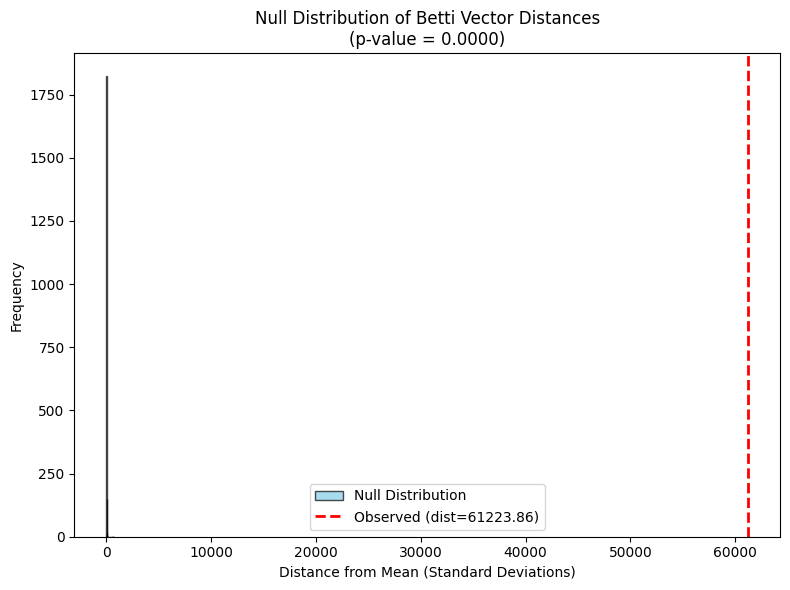

In [26]:
from clique_homology.stats_engine.visualization import plot_null_distribution
plot_null_distribution(null_distribution, observed_betti, quantile)